# Demo 04 — Retrieval Evaluation & the Four Knobs

The runnable notebook behind **§4 (Retrieval Evaluation)** and **§5 (The Four Retrieval Knobs)** of
*Chapter 04 — Inference-Time Retrieval Patterns*. It also **regenerates the five measured charts**
in `lecture notes/images/`.

**Corpus.** The running example is `ragqa_arena_tech` — the same developer-Q&A corpus as the §3
build. Retrieval is **whole-document**: each corpus document is one passage, matching the §3
retriever. Ground truth comes from the examples' `gold_doc_ids`, which are **positional line
indices** into the corpus (`gold_doc_ids = [2822, 2823]` → corpus lines 2822 and 2823). Questions
have on average ~4 relevant documents, so recall@k and hit@k genuinely differ here.

**One exception — Knob 1 (chunking) runs on SQuAD.** ragqa documents are already short and
passage-sized (median ~570 chars), so a chunk-size sweep barely moves on them. Chunking only earns
its keep on long documents, so §5.1 measures it on SQuAD 1.1 dev (Wikipedia paragraphs) — see that
section for the why. Every other result is on `ragqa_arena_tech`.

**No LLM API key needed** — this is pure retrieval (local embeddings + FAISS). An `HF_TOKEN` in your
`.env` is optional (authenticated, faster model downloads); it is loaded automatically if present.

## Part 1 — Setup

Two macOS notes baked in below: PyTorch's **MPS** backend segfaults for this build, so we run on
**CPU**; and `torch` + `faiss` ship separate OpenMP runtimes that clash, so we allow the duplicate
(`KMP_DUPLICATE_LIB_OK`) and pin faiss to a single thread. Neither affects the results.

In [ ]:
# Dependencies (uncomment on Colab or a fresh environment):
# !pip install datasets sentence-transformers faiss-cpu python-dotenv matplotlib pandas
# On Colab: Runtime -> Change runtime type -> T4 GPU makes the embedding sweep ~1-2 min.

In [2]:
import os

# Must be set before torch / faiss import their OpenMP runtimes (macOS: the two clash otherwise).
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import json
import math
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import faiss
from dotenv import load_dotenv
from sentence_transformers import SentenceTransformer

load_dotenv()                    # picks up HF_TOKEN from .env for authenticated model downloads
faiss.omp_set_num_threads(1)     # keep faiss single-threaded to avoid the OpenMP clash with torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# MPS segfaults with this torch build; use CUDA if present, else CPU.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__} | device: {DEVICE}")

# Charts go to the lecture-notes folder when running inside the repo; otherwise to ./charts
# (e.g. on Colab — download them from there afterward and drop into lecture notes/images/).
IMAGES = Path("../../lecture notes/images")
if not IMAGES.exists():
    IMAGES = Path("charts")
    IMAGES.mkdir(exist_ok=True)
CACHE = Path("retrieval_eval_cache")
CACHE.mkdir(exist_ok=True)
print(f"charts -> {IMAGES.resolve()}")

torch 2.11.0+cu128 | device: cuda
charts -> /content/charts


## Part 2 — Load the corpus and gold labels

The corpus is a list of documents; `gold_doc_ids` index it **by line position**. We build each
question's relevant-document set directly from those indices — no answer-string matching needed
(unlike SQuAD in Part 6).

In [3]:
# Fetch the ragqa files if they aren't next to the notebook (e.g. on Colab).
import urllib.request

HF_BASE = "https://huggingface.co/dspy/cache/resolve/main/"
for fn in ["ragqa_arena_tech_corpus.jsonl", "ragqa_arena_tech_examples.jsonl"]:
    if not Path(fn).exists():
        print(f"downloading {fn} ...")
        urllib.request.urlretrieve(HF_BASE + fn, fn)

corpus = [json.loads(line)["text"] for line in open("ragqa_arena_tech_corpus.jsonl")]
examples = [json.loads(line) for line in open("ragqa_arena_tech_examples.jsonl")]
print(f"corpus documents: {len(corpus):,} | examples: {len(examples):,}")

# Ground truth: relevant doc set = the gold line-indices (kept if in range).
questions, relevant_sets = [], []
for e in examples:
    rel = {g for g in e["gold_doc_ids"] if 0 <= g < len(corpus)}
    if rel:
        questions.append(e["question"])
        relevant_sets.append(rel)

n_rel = np.mean([len(r) for r in relevant_sets])
print(f"evaluable questions: {len(questions):,} | avg relevant docs/question: {n_rel:.2f}")

downloading ragqa_arena_tech_corpus.jsonl ...
downloading ragqa_arena_tech_examples.jsonl ...
corpus documents: 28,436 | examples: 2,064
evaluable questions: 2,064 | avg relevant docs/question: 4.21


## Part 3 — The five metrics

For each query we have a ranked list of retrieved document ids and a ground-truth set. Each metric
maps `(retrieved_list, relevant_set) → [0, 1]`. Because questions here are **multi-relevant**,
`recall@k` (how many of the gold docs were found) and `hit@k` (was *any* found) diverge — the point
§4.2 makes.

In [4]:
def recall_at_k(retrieved, relevant, k):
    if not relevant:
        return 0.0
    return len(set(retrieved[:k]) & relevant) / len(relevant)

def hit_at_k(retrieved, relevant, k):
    return 1.0 if (set(retrieved[:k]) & relevant) else 0.0

def precision_at_k(retrieved, relevant, k):
    if k == 0:
        return 0.0
    return len(set(retrieved[:k]) & relevant) / k

def reciprocal_rank(retrieved, relevant):
    for i, doc in enumerate(retrieved, start=1):
        if doc in relevant:
            return 1.0 / i
    return 0.0

def ndcg_at_k(retrieved, relevant, k):
    dcg = sum(1.0 / math.log2(i + 1) for i, doc in enumerate(retrieved[:k], start=1) if doc in relevant)
    n_rel = min(k, len(relevant))
    idcg = sum(1.0 / math.log2(i + 1) for i in range(1, n_rel + 1))
    return (dcg / idcg) if idcg > 0 else 0.0

def evaluate(retrieved_lists, relevant_sets, k_values=(1, 3, 5, 10)):
    out = {}
    for k in k_values:
        out[f"recall@{k}"]    = float(np.mean([recall_at_k(r, s, k)    for r, s in zip(retrieved_lists, relevant_sets)]))
        out[f"hit@{k}"]       = float(np.mean([hit_at_k(r, s, k)       for r, s in zip(retrieved_lists, relevant_sets)]))
        out[f"precision@{k}"] = float(np.mean([precision_at_k(r, s, k) for r, s in zip(retrieved_lists, relevant_sets)]))
        out[f"ndcg@{k}"]      = float(np.mean([ndcg_at_k(r, s, k)      for r, s in zip(retrieved_lists, relevant_sets)]))
    out["mrr"] = float(np.mean([reciprocal_rank(r, s) for r, s in zip(retrieved_lists, relevant_sets)]))
    return out

# Sanity check on synthetic data (multi-relevant)
rel = {42, 99, 77}
ret = [17, 99, 42, 3, 8]
print(f"recall@5    = {recall_at_k(ret, rel, 5):.3f}  (expect 0.667)")
print(f"hit@5       = {hit_at_k(ret, rel, 5):.3f}  (expect 1.000)")
print(f"precision@5 = {precision_at_k(ret, rel, 5):.3f}  (expect 0.400)")
print(f"MRR         = {reciprocal_rank(ret, rel):.3f}  (expect 0.500)")

recall@5    = 0.667  (expect 0.667)
hit@5       = 1.000  (expect 1.000)
precision@5 = 0.400  (expect 0.400)
MRR         = 0.500  (expect 0.500)


## Part 4 — The baseline retriever

The §3 configuration: `all-MiniLM-L6-v2`, whole documents, exact (flat) cosine search. We embed the
whole corpus once per model (cached to disk), embed the queries, and take the top-10 by cosine
similarity.

In [5]:
def add_prefix(model_name, texts, is_query):
    """Use each model as it was trained: e5 needs query:/passage:, bge wants a query
    instruction, MiniLM needs nothing. Skipping these badly handicaps e5/bge."""
    name = model_name.lower()
    if "e5" in name:
        tag = "query: " if is_query else "passage: "
        return [tag + t for t in texts]
    if "bge" in name and is_query:
        return ["Represent this sentence for searching relevant passages: " + t for t in texts]
    return list(texts)

def embed_texts(model, model_name, texts, is_query, batch_size=256, normalize=True):
    texts = add_prefix(model_name, texts, is_query)
    return model.encode(texts, batch_size=batch_size, convert_to_numpy=True,
                        normalize_embeddings=normalize, show_progress_bar=False).astype(np.float32)

def flat_search(query_embs, doc_embs, top_k=10):
    sims = query_embs @ doc_embs.T
    idx = np.argpartition(-sims, top_k, axis=1)[:, :top_k]
    order = np.argsort(-np.take_along_axis(sims, idx, 1), axis=1)
    return np.take_along_axis(idx, order, 1)

_MODELS = {}
def get_model(name):
    if name not in _MODELS:
        _MODELS[name] = SentenceTransformer(name, device=DEVICE)
    return _MODELS[name]

def doc_embeddings(model_name, normalize=True):
    """Embed the whole corpus with `model_name` (prefix-aware), caching to disk."""
    slug = model_name.split("/")[-1] + ("" if normalize else "_raw")
    path = CACHE / f"docs_{slug}_pfx.npy"
    if path.exists():
        return np.load(path)
    t0 = time.time()
    embs = embed_texts(get_model(model_name), model_name, corpus, is_query=False, normalize=normalize)
    np.save(path, embs)
    print(f"  embedded {len(corpus):,} docs with {slug} in {time.time() - t0:.0f}s")
    return embs

def run_pipeline(model_name, top_k=10):
    model = get_model(model_name)
    d_embs = doc_embeddings(model_name)
    q_embs = embed_texts(model, model_name, questions, is_query=True)
    top = flat_search(q_embs, d_embs, top_k=top_k)
    retrieved = [list(top[i]) for i in range(len(questions))]
    metrics = evaluate(retrieved, relevant_sets, k_values=(1, 3, 5, 10))
    return metrics, retrieved

BASELINE_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
baseline_metrics, baseline_retrieved = run_pipeline(BASELINE_MODEL)
for key in ["recall@1", "recall@5", "recall@10", "hit@10", "mrr", "ndcg@10"]:
    print(f"{key:<12} {baseline_metrics[key]:.3f}")

embedded 28,436 docs with all-MiniLM-L6-v2 in 71s
recall@1     0.276
recall@5     0.594
recall@10    0.703
hit@10       0.920
mrr          0.758
ndcg@10      0.653


## Part 5 — The recall@k curve (§4.4)

The most useful single view: recall@k for k = 1…10. Its shape diagnoses the problem — steep-then-flat
means missing coverage; slow-then-high means a ranking problem.

**→ regenerates `rag_recall_curve_baseline.png`**

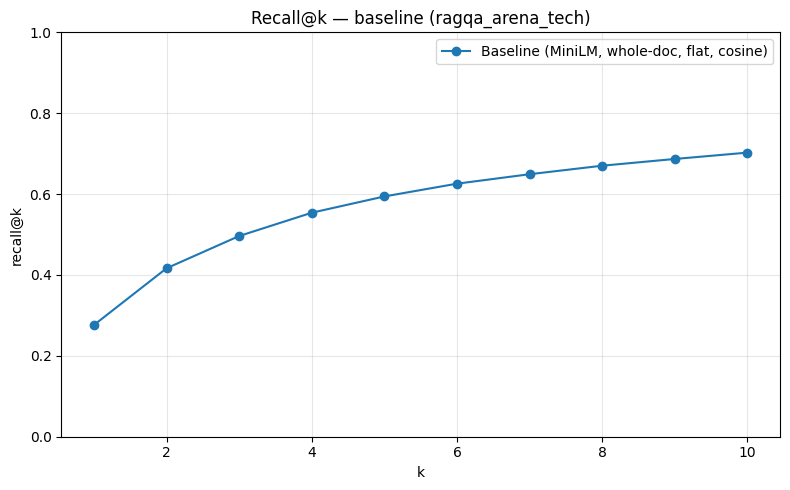

In [6]:
def recall_curve(retrieved_lists, relevant_sets, ks=range(1, 11)):
    return [float(np.mean([recall_at_k(r, s, k) for r, s in zip(retrieved_lists, relevant_sets)])) for k in ks]

def plot_curves(curves, title, fname=None, ks=range(1, 11)):
    plt.figure(figsize=(8, 5))
    for label, ys in curves.items():
        plt.plot(list(ks), ys, marker="o", label=label)
    plt.xlabel("k"); plt.ylabel("recall@k"); plt.title(title)
    plt.ylim(0, 1); plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
    if fname:
        plt.savefig(IMAGES / fname, dpi=150, bbox_inches="tight")
    plt.show()

baseline_curve = recall_curve(baseline_retrieved, relevant_sets)
plot_curves({"Baseline (MiniLM, whole-doc, flat, cosine)": baseline_curve},
            title="Recall@k — baseline (ragqa_arena_tech)",
            fname="rag_recall_curve_baseline.png")

## Part 6 — Knob 1: Chunking, on SQuAD (§5.1)

ragqa documents are already passage-sized, so chunking has almost nothing to do on them. Chunking is
a lever only when documents are **long**, so we measure it on **SQuAD 1.1 dev** — Wikipedia
paragraphs grouped into articles. Here each article is chunked into fixed-token windows, and a chunk
counts as relevant if it (a) comes from the question's article and (b) contains the gold answer
string. This is a **different corpus on purpose** — read it for the chunking lesson, not to compare
absolute numbers with the ragqa results above.

**→ regenerates `rag_recall_by_chunk_size.png`**

In [7]:
from datasets import load_dataset

squad = load_dataset("rajpurkar/squad", split="validation")

# Build per-article corpus: dedupe paragraphs, keep first-appearance order.
articles, para_index, sq_questions = {}, {}, []
for ex in squad:
    title, ctx = ex["title"], ex["context"]
    art = articles.setdefault(title, {"paragraphs": []})
    if (title, ctx) not in para_index:
        para_index[(title, ctx)] = len(art["paragraphs"])
        art["paragraphs"].append(ctx)
    sq_questions.append({"question": ex["question"], "answer": ex["answers"]["text"][0], "title": title})

print(f"SQuAD — articles: {len(articles)} | paragraphs: {sum(len(a['paragraphs']) for a in articles.values()):,} "
      f"| questions: {len(sq_questions):,}")

SQuAD — articles: 48 | paragraphs: 2,067 | questions: 10,570


chunk_size  n_chunks  recall@5  recall@10   mrr  ndcg@10
        128      2007     0.679      0.770 0.661    0.641
        256      1016     0.668      0.774 0.630    0.627
        512       519     0.619      0.761 0.546    0.571
       1024       271     0.669      0.795 0.530    0.577


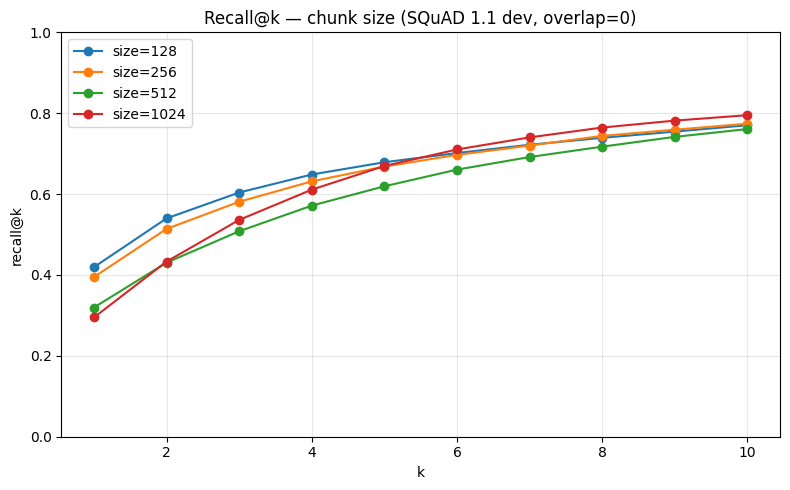

In [8]:
def chunk_text(text, size, overlap):
    """Split into ~`size`-token windows with `overlap` token overlap; return (text, char_start, char_end)."""
    tokens, offsets, i = [], [], 0
    while i < len(text):
        while i < len(text) and text[i].isspace():
            i += 1
        start = i
        while i < len(text) and not text[i].isspace():
            i += 1
        if i > start:
            tokens.append(text[start:i]); offsets.append((start, i))
    if not tokens:
        return []
    chunks, step, s = [], size - overlap, 0
    while s < len(tokens):
        e = min(s + size, len(tokens))
        chunks.append((text[offsets[s][0]:offsets[e - 1][1]], offsets[s][0], offsets[e - 1][1]))
        if e == len(tokens):
            break
        s += step
    return chunks

def build_squad_index(size, overlap):
    """Chunk every article; record which paragraph ids each chunk overlaps."""
    chunks = []
    for title, art in articles.items():
        parts, ranges, cursor = [], [], 0
        for pid, para in enumerate(art["paragraphs"]):
            if parts:
                parts.append("\n\n"); cursor += 2
            parts.append(para); ranges.append((pid, cursor, cursor + len(para))); cursor += len(para)
        full = "".join(parts)
        for ctext, cs, ce in chunk_text(full, size, overlap):
            chunks.append({"title": title, "text": ctext,
                           "para_ids": {pid for pid, s, e in ranges if not (ce <= s or cs >= e)}})
    return chunks

def squad_relevance(chunks):
    """A chunk is relevant to a question if it is in the same article and contains the answer string."""
    by_title = {}
    for cid, c in enumerate(chunks):
        by_title.setdefault(c["title"], []).append((cid, c["text"]))
    q_texts, rels = [], []
    for q in sq_questions:
        rel = {cid for cid, txt in by_title.get(q["title"], []) if q["answer"] in txt}
        if rel:
            q_texts.append(q["question"]); rels.append(rel)
    return q_texts, rels

def run_squad(size, overlap, model_name=BASELINE_MODEL, top_k=10):
    chunks = build_squad_index(size, overlap)
    q_texts, rels = squad_relevance(chunks)
    model = get_model(model_name)
    d_embs = embed_texts(model, model_name, [c["text"] for c in chunks], is_query=False)
    q_embs = embed_texts(model, model_name, q_texts, is_query=True)
    top = flat_search(q_embs, d_embs, top_k=top_k)
    retrieved = [list(top[i]) for i in range(len(q_texts))]
    m = evaluate(retrieved, rels, k_values=(1, 5, 10))
    return m, retrieved, rels, len(chunks)

chunk_rows, chunk_curves = [], {}
for size in [128, 256, 512, 1024]:
    m, ret, rels, n_chunks = run_squad(size, overlap=0)
    chunk_rows.append({"chunk_size": size, "n_chunks": n_chunks,
                       "recall@5": m["recall@5"], "recall@10": m["recall@10"],
                       "mrr": m["mrr"], "ndcg@10": m["ndcg@10"]})
    chunk_curves[f"size={size}"] = recall_curve(ret, rels)

df_chunk = pd.DataFrame(chunk_rows)
print(df_chunk.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
plot_curves(chunk_curves, title="Recall@k — chunk size (SQuAD 1.1 dev, overlap=0)",
            fname="rag_recall_by_chunk_size.png")

## Part 7 — Knob 2: Embedding model (§5.2)

Back on `ragqa_arena_tech`, whole-document retrieval. Four open models, same pipeline, varying only
the embedder. Each model is encoded **the way it was trained** (`add_prefix`): e5 needs
`query:` / `passage:` tags and bge wants a query instruction — omit these and those models score far
below their real quality. **This is the long cell** — it embeds all ~28k documents once per model
(cached to `retrieval_eval_cache/`, so reruns are instant).

**→ regenerates `rag_recall_by_embedding_model.png`**

embedded 28,436 docs with bge-small-en-v1.5 in 191s


embedded 28,436 docs with bge-base-en-v1.5 in 511s


embedded 28,436 docs with e5-base-v2 in 515s
            model  dim  recall@5  recall@10   mrr  ndcg@10
 all-MiniLM-L6-v2  384     0.594      0.703 0.758    0.653
bge-small-en-v1.5  384     0.559      0.662 0.728    0.619
 bge-base-en-v1.5  768     0.583      0.688 0.750    0.644
       e5-base-v2  768     0.582      0.682 0.750    0.639
Best by recall@10: sentence-transformers/all-MiniLM-L6-v2


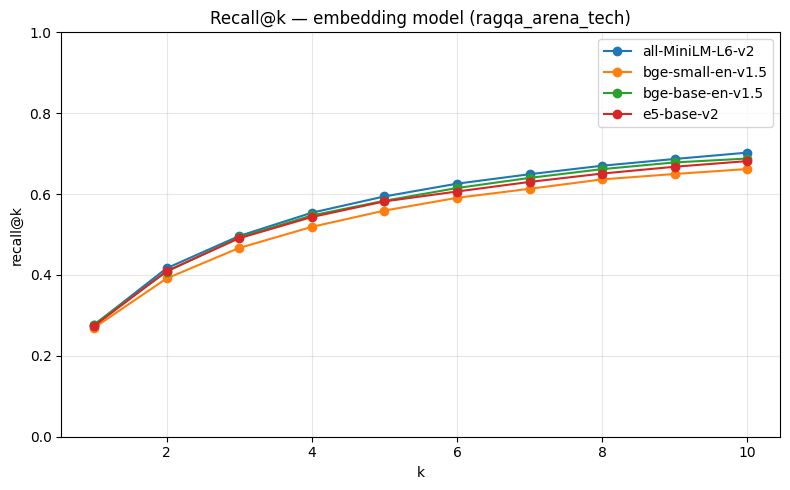

In [9]:
embedding_models = [
    ("sentence-transformers/all-MiniLM-L6-v2", 384),
    ("BAAI/bge-small-en-v1.5", 384),
    ("BAAI/bge-base-en-v1.5", 768),
    ("intfloat/e5-base-v2", 768),
]

emb_rows, emb_curves = [], {}
for name, dim in embedding_models:
    m, ret = run_pipeline(name)
    short = name.split("/")[-1]
    emb_rows.append({"model": short, "dim": dim, "recall@5": m["recall@5"],
                     "recall@10": m["recall@10"], "mrr": m["mrr"], "ndcg@10": m["ndcg@10"]})
    emb_curves[short] = recall_curve(ret, relevant_sets)

df_emb = pd.DataFrame(emb_rows)
print(df_emb.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
best_model = df_emb.loc[df_emb["recall@10"].idxmax(), "model"]
BEST_MODEL = next(n for n, _ in embedding_models if n.endswith(best_model))
print(f"\nBest by recall@10: {BEST_MODEL}")
plot_curves(emb_curves, title="Recall@k — embedding model (ragqa_arena_tech)",
            fname="rag_recall_by_embedding_model.png")

## Part 8 — Knob 3: ANN index (§5.3)

Exact search is `O(N·d)` per query. Approximate Nearest Neighbor (ANN) indexes trade a little recall
for speed. Over the full ~28k-document corpus we compare FAISS **Flat** (exact), **IVF**
(cluster-and-probe), and **HNSW** (graph), measuring recall against exact flat and query latency.

**→ regenerates `rag_ann_pareto.png`**

index  recall_vs_flat  query_ms
       Flat (exact)          1.0000    0.2400
     IVF (nprobe=1)          0.5419    0.0189
     IVF (nprobe=8)          0.8993    0.1241
    IVF (nprobe=16)          0.9473    0.2325
    IVF (nprobe=32)          0.9777    0.4665
 HNSW (efSearch=16)          0.9490    0.0550
 HNSW (efSearch=32)          0.9800    0.1004
 HNSW (efSearch=64)          0.9928    0.1617
HNSW (efSearch=128)          0.9970    0.3026


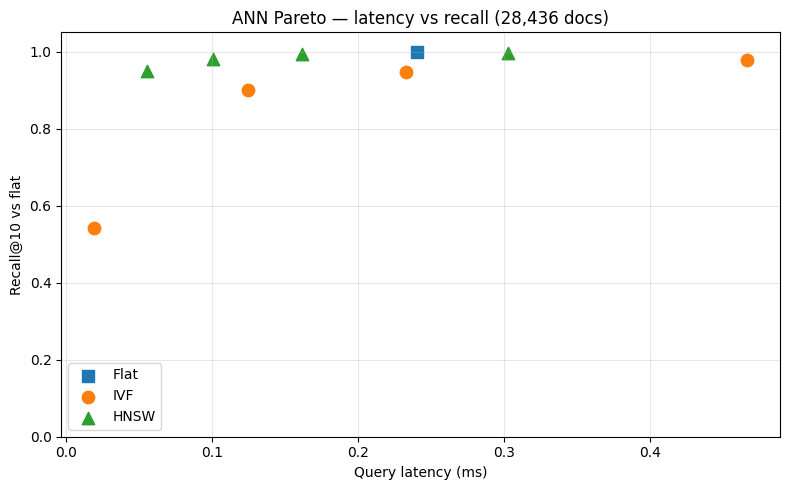

In [10]:
model = get_model(BEST_MODEL)
d_embs = doc_embeddings(BEST_MODEL)
q_embs = embed_texts(model, BEST_MODEL, questions, is_query=True)
n_docs, dim = d_embs.shape

def time_search(index, q, top_k=10):
    t0 = time.time()
    _, top = index.search(q, top_k)
    return top, (time.time() - t0) / len(q) * 1000  # ms/query

flat = faiss.IndexFlatIP(dim); flat.add(d_embs)
flat_top, flat_ms = time_search(flat, q_embs)

rows = [{"index": "Flat (exact)", "recall_vs_flat": 1.0, "query_ms": flat_ms}]

nlist = int(math.sqrt(n_docs))
ivf = faiss.IndexIVFFlat(faiss.IndexFlatIP(dim), dim, nlist, faiss.METRIC_INNER_PRODUCT)
ivf.train(d_embs); ivf.add(d_embs)
for nprobe in [1, 8, 16, 32]:
    ivf.nprobe = nprobe
    top, ms = time_search(ivf, q_embs)
    rec = float(np.mean([len(set(top[i]) & set(flat_top[i])) / 10 for i in range(len(questions))]))
    rows.append({"index": f"IVF (nprobe={nprobe})", "recall_vs_flat": rec, "query_ms": ms})

hnsw = faiss.IndexHNSWFlat(dim, 16, faiss.METRIC_INNER_PRODUCT)
hnsw.hnsw.efConstruction = 64; hnsw.add(d_embs)
for ef in [16, 32, 64, 128]:
    hnsw.hnsw.efSearch = ef
    top, ms = time_search(hnsw, q_embs)
    rec = float(np.mean([len(set(top[i]) & set(flat_top[i])) / 10 for i in range(len(questions))]))
    rows.append({"index": f"HNSW (efSearch={ef})", "recall_vs_flat": rec, "query_ms": ms})

df_ann = pd.DataFrame(rows)
print(df_ann.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

plt.figure(figsize=(8, 5))
for family, marker in [("Flat", "s"), ("IVF", "o"), ("HNSW", "^")]:
    sub = df_ann[df_ann["index"].str.startswith(family)]
    plt.scatter(sub["query_ms"], sub["recall_vs_flat"], s=80, marker=marker, label=family)
plt.xlabel("Query latency (ms)"); plt.ylabel("Recall@10 vs flat")
plt.title(f"ANN Pareto — latency vs recall ({n_docs:,} docs)")
plt.ylim(0, 1.05); plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig(IMAGES / "rag_ann_pareto.png", dpi=150, bbox_inches="tight")
plt.show()

## Part 9 — Knob 4: Similarity metric (§5.4)

Cosine, dot product, and L2 rank identically for **unit-norm** vectors. The only thing that breaks
the tie is unequal norms — i.e. whether you normalized. We compare normalized cosine/dot/L2 against
un-normalized dot on the best model.

In [11]:
d_norm   = doc_embeddings(BEST_MODEL, normalize=True)
d_unnorm = doc_embeddings(BEST_MODEL, normalize=False)
q_norm   = embed_texts(model, BEST_MODEL, questions, is_query=True, normalize=True)
q_unnorm = embed_texts(model, BEST_MODEL, questions, is_query=True, normalize=False)

def eval_scores(q, d, scorer):
    sims = scorer(q, d)
    top = np.argsort(-sims, axis=1)[:, :10]
    retrieved = [list(top[i]) for i in range(len(questions))]
    m = evaluate(retrieved, relevant_sets, k_values=(5, 10))
    return m["recall@5"], m["recall@10"], m["mrr"]

def neg_l2(q, d):
    return -((q * q).sum(1, keepdims=True) + (d * d).sum(1) - 2 * (q @ d.T))

rows = [
    ("cosine (normalized)", *eval_scores(q_norm, d_norm, lambda q, d: q @ d.T)),
    ("dot (normalized)",    *eval_scores(q_norm, d_norm, lambda q, d: q @ d.T)),
    ("L2 (normalized)",     *eval_scores(q_norm, d_norm, neg_l2)),
    ("dot (NOT normalized)", *eval_scores(q_unnorm, d_unnorm, lambda q, d: q @ d.T)),
]
print(pd.DataFrame(rows, columns=["metric", "recall@5", "recall@10", "mrr"]).to_string(
    index=False, float_format=lambda x: f"{x:.3f}"))

embedded 28,436 docs with all-MiniLM-L6-v2_raw in 77s
              metric  recall@5  recall@10   mrr
 cosine (normalized)     0.594      0.703 0.758
    dot (normalized)     0.594      0.703 0.758
     L2 (normalized)     0.594      0.703 0.758
dot (NOT normalized)     0.594      0.703 0.758


## Part 10 — The leaderboard (§5.5)

Stack the recall-moving knobs against the §3 baseline. On this corpus the lever that moves recall is
the **embedding model** (Knob 2); Knob 1 lives on SQuAD, and Knobs 3–4 trade speed / equivalent
ranking rather than recall. So the leaderboard is Baseline → best embedding model.

**→ regenerates `rag_recall_leaderboard.png`**

config  recall@5  recall@10   mrr
          Baseline (MiniLM)     0.594      0.703 0.758
+ Knob 2 (all-MiniLM-L6-v2)     0.594      0.703 0.758


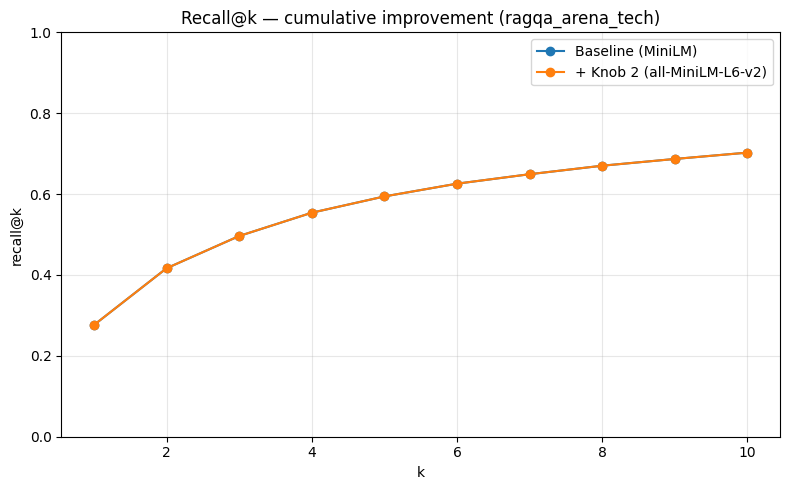

In [12]:
lb_rows, lb_curves = [], {}
lb_rows.append({"config": "Baseline (MiniLM)", "recall@5": baseline_metrics["recall@5"],
                "recall@10": baseline_metrics["recall@10"], "mrr": baseline_metrics["mrr"]})
lb_curves["Baseline (MiniLM)"] = baseline_curve

m, ret = run_pipeline(BEST_MODEL)
lb_rows.append({"config": f"+ Knob 2 ({BEST_MODEL.split('/')[-1]})", "recall@5": m["recall@5"],
                "recall@10": m["recall@10"], "mrr": m["mrr"]})
lb_curves[f"+ Knob 2 ({BEST_MODEL.split('/')[-1]})"] = recall_curve(ret, relevant_sets)

print(pd.DataFrame(lb_rows).to_string(index=False, float_format=lambda x: f"{x:.3f}"))
plot_curves(lb_curves, title="Recall@k — cumulative improvement (ragqa_arena_tech)",
            fname="rag_recall_leaderboard.png")

## Summary

- **Metrics (§4):** on multi-relevant ragqa, recall@k and hit@k diverge; pick the metric that
  matches your setting (§4.3).
- **Knob 1 — chunking (§5.1, SQuAD):** matters on long documents; near-neutral on already-short
  corpora like ragqa.
- **Knob 2 — embedding model (§5.2):** the highest-leverage recall lever here.
- **Knob 3 — ANN index (§5.3):** trades recall for latency; the shape is what scales to millions.
- **Knob 4 — similarity metric (§5.4):** neutral once vectors are normalized.

Five charts written to `lecture notes/images/`:
`rag_recall_curve_baseline`, `rag_recall_by_chunk_size`, `rag_recall_by_embedding_model`,
`rag_ann_pareto`, `rag_recall_leaderboard`.